I am training a model on heart disease dataset

In [1]:
#writing requirements file for python package version needed
requirements = """
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>5.15.0
ydata-profiling>=4.5.0
scikit-learn==1.9.0
###dataset package
ucimlrepo==0.0.7
joblib>=1.2.0
"""
with open("requirements.txt","w") as f:
    f.write(requirements)

In [2]:
#installing the packages from requirements file
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.

In [3]:
from ucimlrepo import list_available_datasets

#listing the datasets available in the ucimlrepo package
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [4]:
#retrieve the dataset from the ucimlrepo package
from ucimlrepo import fetch_ucirepo as fetch_dataset
import pandas as pd

heart_disease = fetch_dataset(name="Heart Disease")
heart_disease_df = pd.concat([heart_disease.data['features'], heart_disease.data['targets']], axis=1)
#save the dataset as a csv file
heart_disease_df.to_csv("heart_disease.csv", index=False)


In [5]:
#loading the dataset and inspecting the dataset

dataset = pd.read_csv("heart_disease.csv")
dataset.shape

(303, 14)

In [6]:
from ydata_profiling import ProfileReport

#performing exploratory data analysis using the ydata_profiling package and
#  saving the report as an html file
profile = ProfileReport(dataset, title="Heart Disease EDA Report", explorative=True)
profile.to_file("heart_disease_report.html")

/tmp/ipykernel_15450/93771893.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 80.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [8]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [9]:
#rename the target column to "target"
dataset["target"] = dataset['num']
dataset.drop(columns=["num"], inplace=True)
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [10]:
#change the target column to binary values since the target column has values from 0 to 4 where 0 
# means no heart disease and 1,2,3,4 means heart disease
dataset["target"] = dataset['target'].apply(lambda s: 1 if s>0 else 0)
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [11]:
dataset.duplicated().sum()

np.int64(0)

In [12]:
dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [13]:
#checking the dataset for target data imbalance
dataset["target"].value_counts()/len(dataset)

,count
target,
0,0.541254
1,0.458746


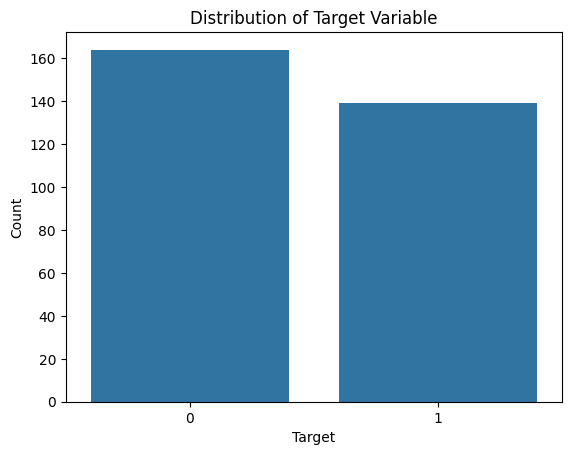

In [14]:
#plotting the target variable distribution using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=dataset)
plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

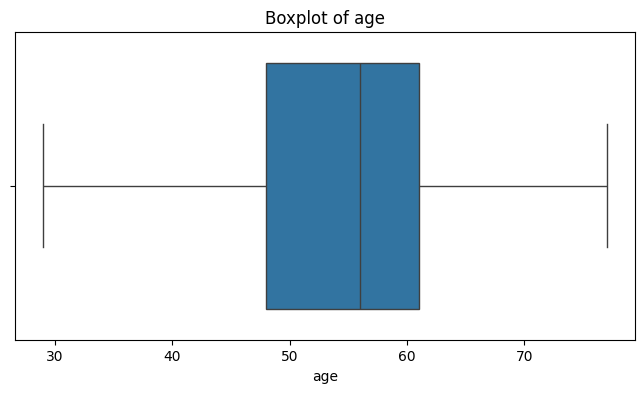

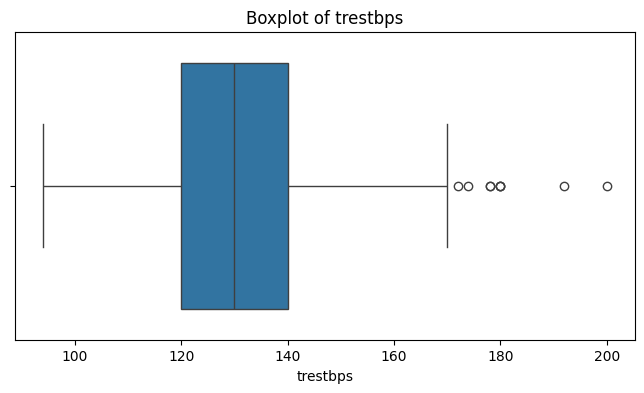

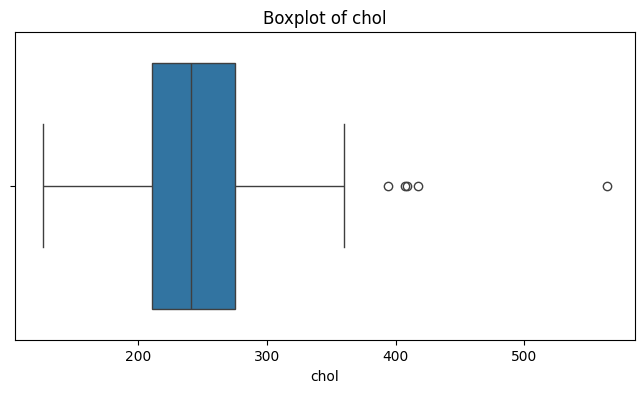

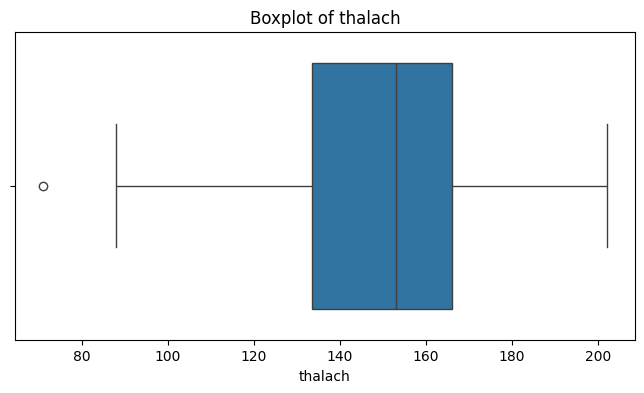

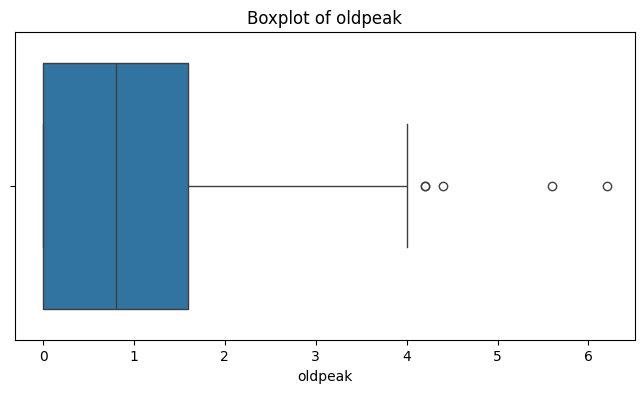

In [15]:
#checking the outliers in the dataset using boxplot
numeric_columns = dataset.drop(columns=["target","sex","cp","fbs","restecg","exang","slope","ca","thal"])
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataset[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

Because oldpeak, chol, trestbps have outliers i am using robustscaler since i dont want to remove it
Now i need to split the dataset then impute the missing value then scale it to remove the outlier

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.model_selection import train_test_split

# prepare X and y
X = dataset.drop(columns=['target'])
y = dataset['target']

numerical_col = ["age", "trestbps", "chol", "thalach", "oldpeak"]
category_col = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]  # removed 'target'

numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
category_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preproc = ColumnTransformer([
    ('num', numerical_pipe, numerical_col),
    ('cat', category_pipe, category_col)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preproc.fit_transform(X_train)
X_test_processed = preproc.transform(X_test)

# get feature names (fallback to manual list if not available)
try:
    feature_names = preproc.get_feature_names_out()
except Exception:
    feature_names = numerical_col + category_col

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_train_df['target'] = y_train.values

profile = ProfileReport(X_train_df, title="Train split EDA", explorative=True)
profile.to_file("train_split_profile.html")
X_test_processed = preproc.transform(X_test)



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 80.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
from google.colab import files
files.download('/content/train_split_profile.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Support Vector Machine": SVC()
}

for name, model in models.items():
    pipe = Pipeline([('preproc', preproc), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f"{name} F1 Score: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression F1 Score: 0.7994 (+/- 0.0292)
Random Forest F1 Score: 0.7668 (+/- 0.0517)
XGBoost F1 Score: 0.7676 (+/- 0.0521)
Support Vector Machine F1 Score: 0.7749 (+/- 0.0495)


In [21]:
%pip install lime==0.2.0.1



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a2916556b1a2a9a5968e1058cfcc026066f9f9a3f462c01c3e3694529cafcc74
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,precision_score,recall_score,confusion_matrix,roc_auc_score
import joblib
from lime.lime_tabular import LimeTabularExplainer
import dill

pipe = Pipeline([('preproc', preproc),('clf', LogisticRegression())])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps['clf'], "predict_proba") else None  

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Unlikely', 'Likely'],
    mode="classification",
    discretize_continuous=False
)

joblib.dump(pipe, 'heart_disease_model.joblib')
with open("lime_explainer.pkl","wb") as f:
    dill.dump(explainer,f)

print('F1', f1_score(y_test, y_pred))
print('Precision', precision_score(y_test, y_pred))
print('Recall', recall_score(y_test, y_pred))
if y_proba is not None:
    print('ROC AUC', roc_auc_score(y_test, y_proba))
print('Confusion matrix:\\n', confusion_matrix(y_test, y_pred))

F1 0.8923076923076924
Precision 0.8787878787878788
Recall 0.90625
ROC AUC 0.9245689655172413
Confusion matrix:\n [[25  4]
 [ 3 29]]
